In [2]:
### Import modules
import numpy as np
from timeit import timeit
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from numba import njit, prange

# Define test functions

## Function 1

In [3]:
### Define control matrix product
def slow_matrix_product(mat1, mat2):
    """
    Multiplies the two input matrices using nested for loops
    """
    assert mat1.shape[1] == mat2.shape[0]
    result = []
    for r in range (mat1.shape[0]):
        row = []
        for c in range (mat2.shape[1]):
            val = 0
            for i in range (mat1.shape[1]):
                val += mat1[r,i]*mat2[i,c]
            row.append(val)
        result.append(row)
    return result
    
matrix1 = np.random.rand(10, 7)
matrix2 = np.random.rand(7, 10)

# Check function against M1@M2
for i in range(2,5):
    matrix1 = np.random.rand(i, 4)
    matrix2 = np.random.rand(4, i)
    assert np.allclose(slow_matrix_product(matrix1, matrix2), matrix1 @ matrix2)
print('All tests passed')


All tests passed


## Function 2

Faster matrix product imporves slow matrix product in two ways.

1. Eliminates the third for loop and replaces it with the precompiled NumPy.dot, notably improving rumtim (see bleow).

2. Preallocates memory of result matrix

In [4]:
### Define partially optimised matrix product function 
# Introduces NumPy functionality into loop 

def fast_matrix_product(mat1, mat2):
    """
    Multiplies the two input matrices
    """
    assert mat1.shape[1] == mat2.shape[0]
    result = np.zeros((mat1.shape[0],mat2.shape[1]))
    for r in prange(mat1.shape[0]):
        for c in range(mat2.shape[1]):
            result[r,c] = np.dot(mat1[r,:], mat2[:,c])
    return(result)

# Check function against M1@M2
for i in range(2,5):
    matrix1 = np.random.rand(i, 4)
    matrix2 = np.random.rand(4, i)
    assert np.allclose(fast_matrix_product(matrix1, matrix2), matrix1 @ matrix2)
print('All tests passed')


All tests passed


## Function 3

In [5]:
### Define further optimised matrix product function 
# Utilises Numba's njit decorator and prange (parallel range) functionality in top level loop

@njit(parallel=True, fastmath=True, cache=True)
def numba_matrix_product(mat1, mat2):
    """
    Multiplies matrix 1 by matrix 2.
    Optimised version of faster_matrix_product with following Numba changes.

    1. Implimented JIT compiling.
    2. Implimented parallelisation and caching.
    3. Implimented fastmath.
    """
    assert mat1.shape[1] == mat2.shape[0]
    result = np.zeros((mat1.shape[0],mat2.shape[1]))
    for r in prange(mat1.shape[0]):
        for c in range(mat2.shape[1]):
            result[r,c] = np.dot(mat1[r,:], mat2[:,c])
    return(result)

# Check function against M1@M2
for i in range(2,5):
    matrix1 = np.random.rand(i, 4)
    matrix2 = np.random.rand(4, i)
    assert np.allclose(numba_matrix_product(matrix1, matrix2), matrix1 @ matrix2)
print('All tests passed')

#print(numba_matrix_product.inspect_types())

All tests passed


In [6]:
### Compare runtime of above methods for large input matrices
mat1 = np.random.rand(100,100)
mat2 = np.random.rand(100,100)

def numpy_matrix_product(mat1,mat2):
  "Function wrapper for M1@M2"
  return(mat1@mat2)

functions = (slow_matrix_product, fast_matrix_product, numba_matrix_product, numpy_matrix_product)

loops = 10
for func in functions:
    t = timeit(lambda: func(mat1, mat2), number=loops)
    print(f'Runtime for {func.__name__} = {t/loops:.6f}s (Average over {loops} loops)')

Runtime for slow_matrix_product = 0.172414s (Average over 10 loops)
Runtime for fast_matrix_product = 0.006403s (Average over 10 loops)
Runtime for numba_matrix_product = 0.000239s (Average over 10 loops)
Runtime for numpy_matrix_product = 0.000357s (Average over 10 loops)


# Benchmark performance

In [7]:
### Plot times for range of nxn matrices and functions.
# Define some useful functions

def generate_test_matrices(size_list):
  '''
  Generates an array of nxn matrix pairs for each element n in size_list
  '''
  mats = []
  for n in (size_list):
      mat1 = np.random.rand(n,n)
      mat2 = np.random.rand(n,n)
      mats.append((mat1,mat2))
  return(mats)

def get_function_time_data(*args,size_list,loops):
  '''
  Measures the average runtime of multiple matrix multiplication functions for different matrix dimensions.

  Parameters:
  *args: list of input functions
  dims: list of matrix dimensions
  loops: number of executions averaged over

  return: list of average times for each function across input dimensions.
  '''
  mats = generate_test_matrices(size_list)
  mat_product_time_data = []
  for func in args:
      avg_times = []
      i = 1
      for pair in mats:
        t = timeit(lambda: func(pair[0], pair[1]), number=loops)
        avg_times.append(t/loops)
        print(f'Current function: {func.__name__}, Iteration: {i}/{len(mats)}', end='\r')
        i += 1
      mat_product_time_data.append(avg_times)
  return mat_product_time_data

In [8]:
### Generate data spread for matrix product times, across given matirx size range.

product_functions = (slow_matrix_product,fast_matrix_product,numba_matrix_product,numpy_matrix_product)
ns = np.linspace(2,1024,15,dtype = int)
loops = 5

mat_product_times = get_function_time_data(*product_functions, size_list = ns,loops = loops)

Text(0.5, 1.0, 'Plot of matrix product function runtimes.')

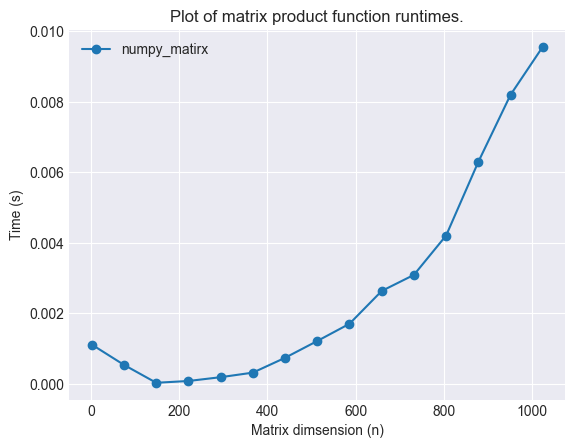

In [13]:
### Unpack data
slow_times = mat_product_times[0]
fast_times = mat_product_times[1]
numba_times = mat_product_times[2]
numpy_times = mat_product_times[3]

### Plot data.
plt.style.use('seaborn-v0_8-darkgrid')
#plt.plot(ns, slow_times,'-o', label = 'slow_matrix')
#plt.plot(ns, fast_times,'-o', label = 'faster_matrix')
#plt.plot(ns, numba_times,'-o', label = 'numba_matrix')
plt.plot(ns, numpy_times,'-o', label = 'numpy_matirx')

#plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.xlabel('Matrix dimsension (n)')
plt.ylabel('Time (s)')
plt.title('Plot of matrix product function runtimes.')

## Part 2

Make a plot that compares the times taken by your JIT compiled function when the inputs have different combinations of C-style and Fortran-style ordering (ie the plot should have lines for when both inputs are C-style, when the first is C-style and the second is Fortran-style, and so on).

In [ ]:
### Generate four sets of matrices with varying memory types.

n = np.linspace(2,1024,15,dtype = int)
mats = matrix_maker(n)
cc_mats = mats # C-Order by default
cf_mats = mats # Initiaise memory matrices before overwriting
fc_mats = mats
ff_mats = mats

for i, (mat1, mat2) in enumerate(cc_mats):
    cf_mats[i] = (mat1, np.asfortranarray(mat2)) # cf - mat1: c style, mat 2: fotrtan style.

for i, (mat1, mat2) in enumerate(cc_mats):
    fc_mats[i] = (np.asfortranarray(mat1), mat2)

for i, (mat1, mat2) in enumerate(cc_mats):
    ff_mats[i] = (np.asfortranarray(mat1), np.asfortranarray(mat2))

In [ ]:
### Generate data

mem_mats = [cc_mats, cf_mats, fc_mats, ff_mats]

part2_2_times = []
for mat in mem_mats:
    times = get_function_time_data(numba_faster_matrix_product, matrices = mat,loops = 10)
    part2_2_times.append(times[0])

  0%|          | 0/15 [00:00<?, ?it/s]

<ipython-input-60-73a9a0ab6c34>:20: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'F', False, aligned=True))
  result[r,c] = np.dot(mat1[r,:], mat2[:,c])


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Plot of matrix product function runtimes.')

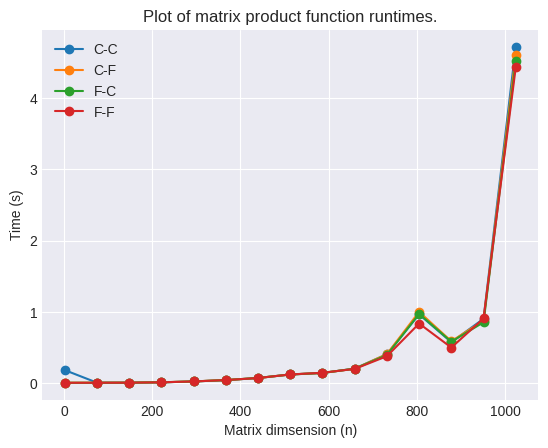

In [ ]:
### Plot data

plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(n, part2_2_times[0],'-o', label = 'C-C')
plt.plot(n, part2_2_times[1],'-o', label = 'C-F')
plt.plot(n, part2_2_times[2],'-o', label = 'F-C')
plt.plot(n, part2_2_times[3],'-o', label = 'F-F')
#plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.xlabel('Matrix dimsension (n)')
plt.ylabel('Time (s)')
plt.title('Plot of matrix product function runtimes.')

####Plot expectations and observations

We expect CC-style ordering to be the fastest because its memory access is contiguous, optimising cache usage. For mixed memory orderings (C-F, F-C), performance tends to slow down due to less efficient memory access, leading to more cache misses. The F-F combination can perform well as if the algorithm consistently accesses elements column-wise, leading to optimised cache usage.

However, in this plot we don't observe much of a disparity between the different styles. This is most likely a result of Numba's under the hood optimisations.



